<a href="https://colab.research.google.com/github/scottspurlock/csc4466-s2026/blob/main/tutorials/day23_object_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computer Vision
## Day 23 Object Detection

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

import os

import torch
import torchvision.transforms as T
import torchvision
import torch

## Download an image

--2026-04-25 19:56:50--  https://images.unsplash.com/photo-1484704324500-528d0ae4dc7d
Resolving images.unsplash.com (images.unsplash.com)... 151.101.2.208, 151.101.66.208, 151.101.130.208, ...
Connecting to images.unsplash.com (images.unsplash.com)|151.101.2.208|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2792764 (2.7M) [image/jpeg]
Saving to: ‘birds.jpg’

birds.jpg           100%[===================>]   2.66M  --.-KB/s    in 0.04s   

2026-04-25 19:56:50 (59.3 MB/s) - ‘birds.jpg’ saved [2792764/2792764]



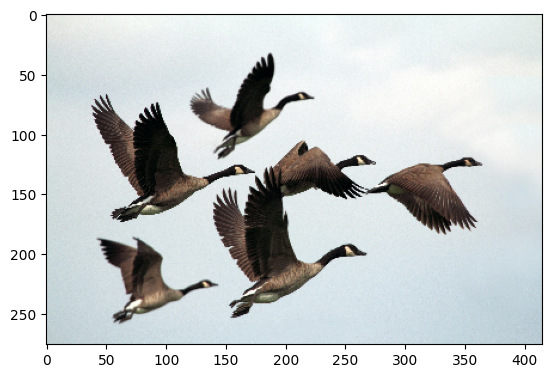

In [3]:
! wget https://images.unsplash.com/photo-1484704324500-528d0ae4dc7d -O birds.jpg

img = cv2.imread('birds.jpg')[:, :, ::-1]

# if the image is big, resizing can make things run faster
img = cv2.resize(img, None, fx=0.08, fy=0.08)
plt.imshow(img)

## Download the pretrained detection model (and weights)

In [4]:
# get the pretrained model from torchvision.models
weights = torchvision.models.detection.FasterRCNN_ResNet50_FPN_V2_Weights.COCO_V1
model = torchvision.models.detection.fasterrcnn_resnet50_fpn_v2(weights=weights)

# model.eval() to use the model for inference (no training)
model.eval()

# Coco class labels
# Note that there are some N/A's
COCO_LABELS = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
    'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table',
    'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book',
    'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:01<00:00, 155MB/s]


## run model on image

In [5]:
# convert image from numpy array to pytorch tensor (and make it channels first)
transform = T.Compose([T.ToTensor()])
x = transform(img.copy())
x.size()

torch.Size([3, 276, 415])

In [6]:
# pass image through model
pred = model([x])

# pred is a list (one for each input image)
# since there's just one image
pred = pred[0]

# each prediction is a dictionary:
# - boxes: list of boxes (4 coordinates)
# - labels: list of indexes based on COCO label names
# - scores: list of confidence values for the detections
pred

{'boxes': tensor([[121.5489,  32.5805, 223.8454, 122.8853],
         [ 44.4313, 185.4299, 143.9276, 257.8921],
         [266.6811, 120.6488, 366.0985, 184.2181],
         [ 38.8658,  66.4915, 175.5827, 173.3326],
         [140.1969, 121.1241, 268.3987, 253.7729],
         [177.5876, 104.9520, 274.4732, 156.4102],
         [210.4368, 106.2594, 218.5706, 119.6531],
         [ 55.4829,  86.1401, 268.6776, 221.3607],
         [ 69.1847,  48.1751, 271.0675, 164.8980],
         [187.3917,  64.9002, 224.4905,  80.6826]], grad_fn=<StackBackward0>),
 'labels': tensor([16, 16, 16, 16, 16, 16, 16, 16, 16, 16]),
 'scores': tensor([0.9956, 0.9954, 0.9944, 0.9920, 0.9460, 0.8456, 0.4476, 0.0971, 0.0666,
         0.0633], grad_fn=<IndexBackward0>)}

## Display boxes on image

+ keeping confidence 1.00
[121.54887  32.58048 223.84541 122.8853 ]
+ keeping confidence 1.00
[ 44.43125 185.42995 143.92761 257.89212]
+ keeping confidence 0.99
[266.68112 120.64876 366.09854 184.21811]
+ keeping confidence 0.99
[ 38.86582  66.49152 175.58273 173.33258]
+ keeping confidence 0.95
[140.19685  121.124146 268.3987   253.77286 ]
+ keeping confidence 0.85
[177.58762 104.95198 274.4732  156.41016]
- discarding confidence 0.45
- discarding confidence 0.10
- discarding confidence 0.07
- discarding confidence 0.06


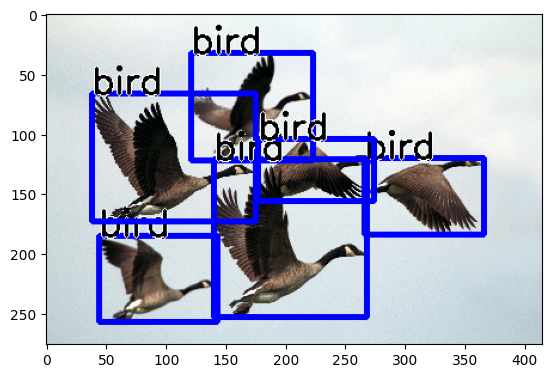

In [7]:
SCORE_THRESH = 0.5

disp = img.copy()
num_detections = len(pred['boxes'])

for i in range(num_detections):
    # score
    score = pred['scores'][i].detach().numpy()

    # ignore low confidence detections
    if score < SCORE_THRESH:
        print(f'- discarding confidence {score:.2f}')
        continue
    else:
        print(f'+ keeping confidence {score:.2f}')

    # bounding box
    box = pred['boxes'][i].detach().numpy()
    print(box)
    top_left = (int(box[0]), int(box[1]))
    bottom_right = (int(box[2]), int(box[3]))

    # draw the bounding box on the image
    cv2.rectangle(disp, top_left, bottom_right, color=(0, 0, 255), thickness=4)

    # label - show detected object type
    label_idx = pred['labels'][i].detach().numpy()
    label = COCO_LABELS[label_idx]

    # draw white text, then black on top to show up better
    cv2.putText(disp, label, top_left, cv2.FONT_HERSHEY_SIMPLEX, fontScale=1, color=[255, 255, 255], thickness=4)
    cv2.putText(disp, label, top_left, cv2.FONT_HERSHEY_SIMPLEX, fontScale=1, color=[0, 0, 0], thickness=2)

plt.imshow(disp)

# Mask R-CNN
This model does instance segmentation (finds masks)

In [8]:
# get the pretrained model from torchvision.models
weights = torchvision.models.detection.MaskRCNN_ResNet50_FPN_V2_Weights.COCO_V1
model = torchvision.models.detection.maskrcnn_resnet50_fpn_v2(weights=weights)

# model.eval() to use the model for inference (no training)
model.eval()

print('Mask R-CNN loaded')

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_v2_coco-73cbd019.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_v2_coco-73cbd019.pth


100%|██████████| 177M/177M [00:01<00:00, 155MB/s]


Mask R-CNN loaded


## Run the image through the model

In [9]:
# convert image from numpy array to pytorch tensor (and make it channels first)
transform = T.Compose([T.ToTensor()])
x = transform(img.copy())

# pass image through model
pred = model([x])

# pred is a list (one for each input image)
# since there's just one image
pred = pred[0]

# each prediction is a dictionary:
# - boxes: list of boxes (4 coordinates)
# - labels: list of indexes based on COCO label names
# - scores: list of confidence values for the detections
# - masks: multi-dimensional array (tensor) to indicate which pixels are in the mask
pred

{'boxes': tensor([[120.6270,  33.0088, 223.3876, 122.2908],
         [ 42.4351, 185.7800, 142.5751, 259.8535],
         [265.1202, 120.2161, 364.8771, 183.5164],
         [ 39.1494,  66.1571, 171.6735, 173.4819],
         [138.5939, 118.6918, 267.6443, 256.5157],
         [178.5249, 106.4867, 275.9228, 155.5748],
         [149.8240, 110.0716, 275.6386, 195.7825],
         [ 41.6848,  57.0958, 264.8763, 184.9727],
         [ 87.8998,  58.9886, 394.8537, 248.6140]], grad_fn=<StackBackward0>),
 'labels': tensor([16, 16, 16, 16, 16, 16, 16, 16, 16]),
 'scores': tensor([0.9976, 0.9968, 0.9960, 0.9920, 0.9908, 0.8737, 0.1151, 0.0658, 0.0606],
        grad_fn=<IndexBackward0>),
 'masks': tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]],
 
 
         [[[0., 0., 0.,  ..., 0

In [10]:
# from https://github.com/multimodallearning/pytorch-mask-rcnn/blob/master/visualize.py
def apply_mask(image, mask, color, alpha=0.5):
    for c in range(3):
        image[:, :, c] = np.where(mask == 255,
                                  image[:, :, c] *
                                  (1 - alpha) + alpha * color[c] * 255,
                                  image[:, :, c])
    return image


+ keeping confidence 1.00
bird


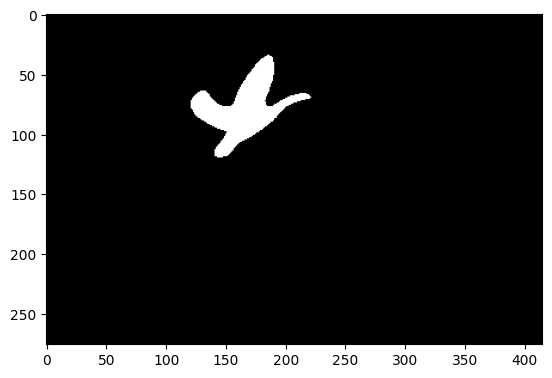

+ keeping confidence 1.00
bird


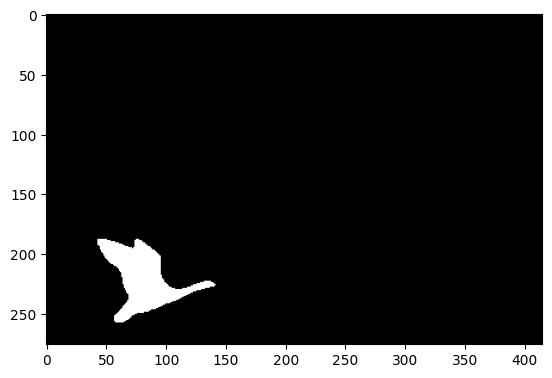

+ keeping confidence 1.00
bird


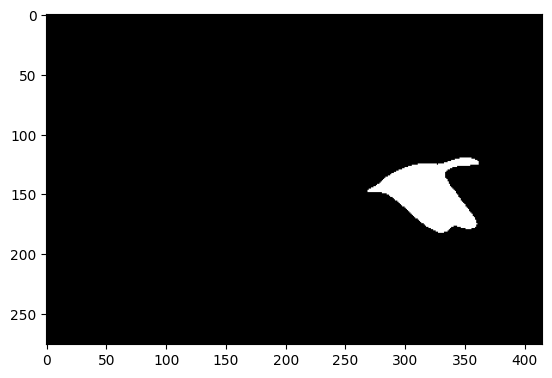

+ keeping confidence 0.99
bird


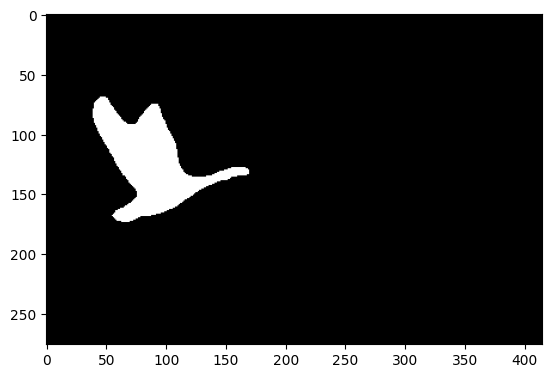

+ keeping confidence 0.99
bird


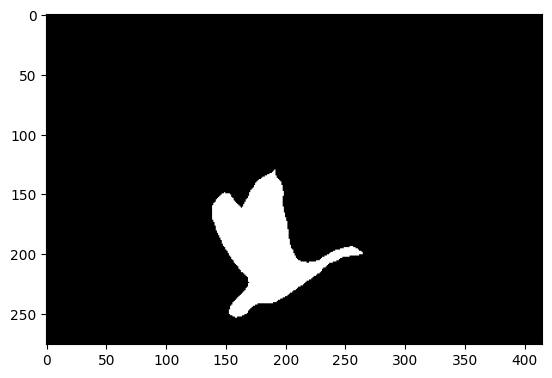

+ keeping confidence 0.87
bird


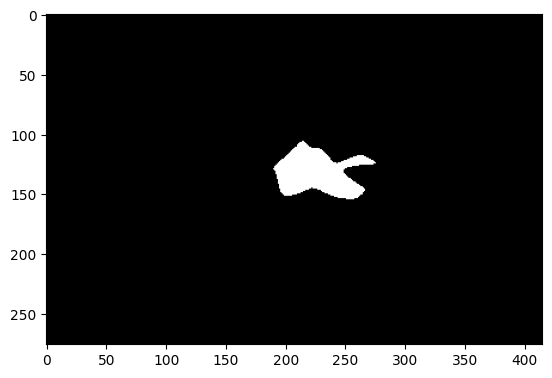

- discarding confidence 0.12
- discarding confidence 0.07
- discarding confidence 0.06


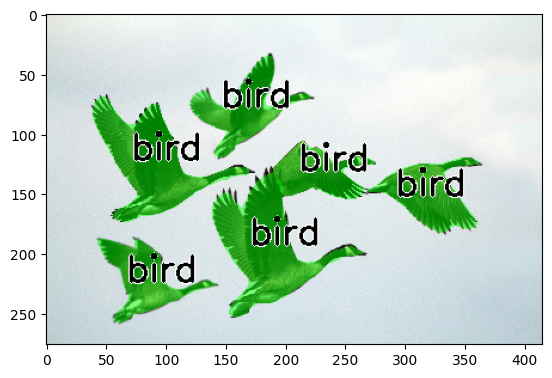

In [12]:
SCORE_THRESH = 0.5

disp = img.copy()
num_detections = len(pred['boxes'])

for i in range(num_detections):
    # score
    score = pred['scores'][i].detach().numpy()
    if score < SCORE_THRESH:
        print(f'- discarding confidence {score:.2f}')
        continue
    else:
        print(f'+ keeping confidence {score:.2f}')

    # label
    label_idx = pred['labels'][i].detach().numpy()
    label = COCO_LABELS[label_idx]
    print(label)

    # mask
    mask = pred['masks'][i].detach().numpy()[0]
    mask[mask >= 0.5] = 255
    mask[mask < 0.5] = 0
    mask = mask.astype('uint8')
    plt.imshow(mask, cmap='gray')
    plt.show()

    # apply mask to image
    green = [0, 1, 0]
    disp = apply_mask(disp, mask, green)

    # bounding box around contour
    contours, _ = cv2.findContours(mask.copy(),
            cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x, y, w, h = cv2.boundingRect(contours[0])

    # show label
    cv2.putText(disp, label, (x+w//4, y+h//2), cv2.FONT_HERSHEY_SIMPLEX, fontScale=1, color=[255, 255, 255], thickness=3)
    cv2.putText(disp, label, (x+w//4, y+h//2), cv2.FONT_HERSHEY_SIMPLEX, fontScale=1, color=[0, 0, 0], thickness=2)

plt.imshow(disp)